# # Phone Addiction Prediction
# **Phase 1: Data Cleaning, EDA, Pattern Analysis, and Machine Learning**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [5]:
df = pd.read_csv(r"C:\Users\waelw\Downloads\data_mining\Smartphone_Usage_And_Addiction_Analysis_7500_Rows (1).csv")

In [6]:
display(df.head())


,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [7]:
display(df.info())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

None

transaction_id               0
user_id                      0
age                          0
gender                       0
daily_screen_time_hours      0
social_media_hours           0
gaming_hours                 0
work_study_hours             0
sleep_hours                  0
notifications_per_day        0
app_opens_per_day            0
weekend_screen_time          0
stress_level                 0
academic_work_impact         0
addiction_level            819
addicted_label               0
dtype: int64

2. Data Cleaning & Preprocessing

In [8]:
df_cleaned = df.drop(['transaction_id', 'user_id'], axis=1)

In [9]:
df_cleaned = df_cleaned.drop(['addiction_level'], axis=1)

In [10]:
stress_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
impact_mapping = {'No': 0, 'Yes': 1}
df_cleaned['stress_level'] = df_cleaned['stress_level'].map(stress_mapping)
df_cleaned['academic_work_impact'] = df_cleaned['academic_work_impact'].map(impact_mapping)


In [11]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['gender'], drop_first=True)

print("Data cleaning complete. Cleaned dataset shape:", df_cleaned.shape)


Data cleaning complete. Cleaned dataset shape: (7500, 14)


 ## 3. Exploratory Data Analysis (EDA)

C:\Users\waelw\AppData\Local\Temp\ipykernel_2352\869930149.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='addicted_label', data=df_cleaned, palette='viridis')


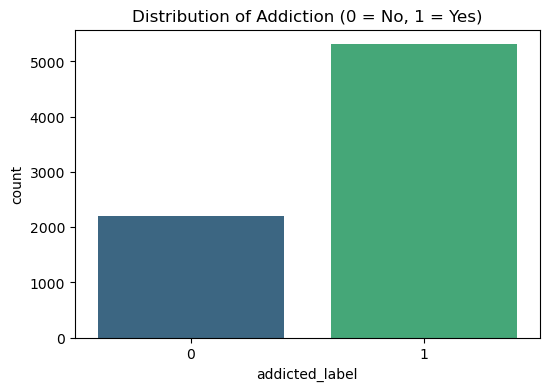

In [12]:
# Plot 1: Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='addicted_label', data=df_cleaned, palette='viridis')
plt.title('Distribution of Addiction (0 = No, 1 = Yes)')
plt.show()

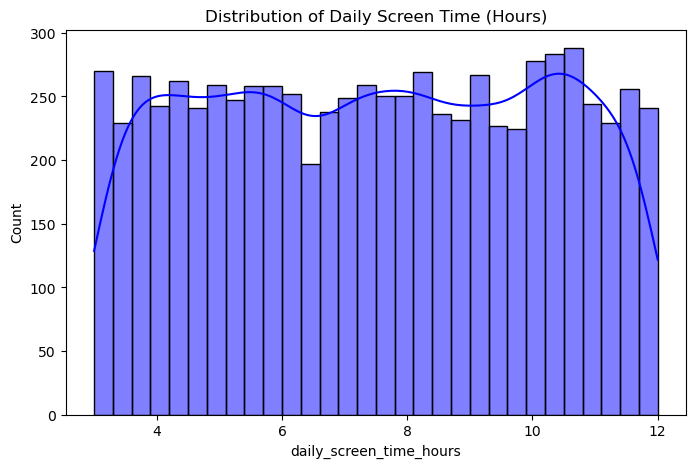

In [13]:
# Plot 2: Daily Screen Time Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_cleaned['daily_screen_time_hours'], kde=True, bins=30, color='blue')
plt.title('Distribution of Daily Screen Time (Hours)')
plt.show()


C:\Users\waelw\AppData\Local\Temp\ipykernel_2352\4221090682.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=df_cleaned, palette='Set2')


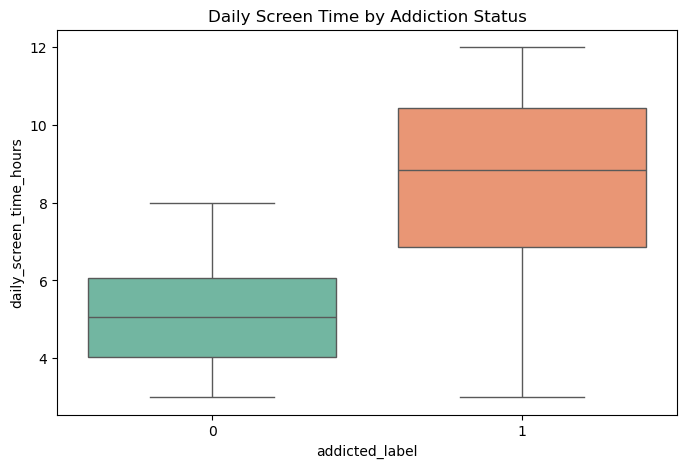

In [14]:
# Plot 3: Screen time vs Addicted Label
plt.figure(figsize=(8, 5))
sns.boxplot(x='addicted_label', y='daily_screen_time_hours', data=df_cleaned, palette='Set2')
plt.title('Daily Screen Time by Addiction Status')
plt.show()

#  4. Pattern Analysis: Covariance and Correlation

In [15]:
# Calculate Covariance
cov_matrix = df_cleaned.cov()
print("Covariance between Screen Time and Social Media Hours:", 
      cov_matrix.loc['daily_screen_time_hours', 'social_media_hours'])

Covariance between Screen Time and Social Media Hours: 0.04269299899186547


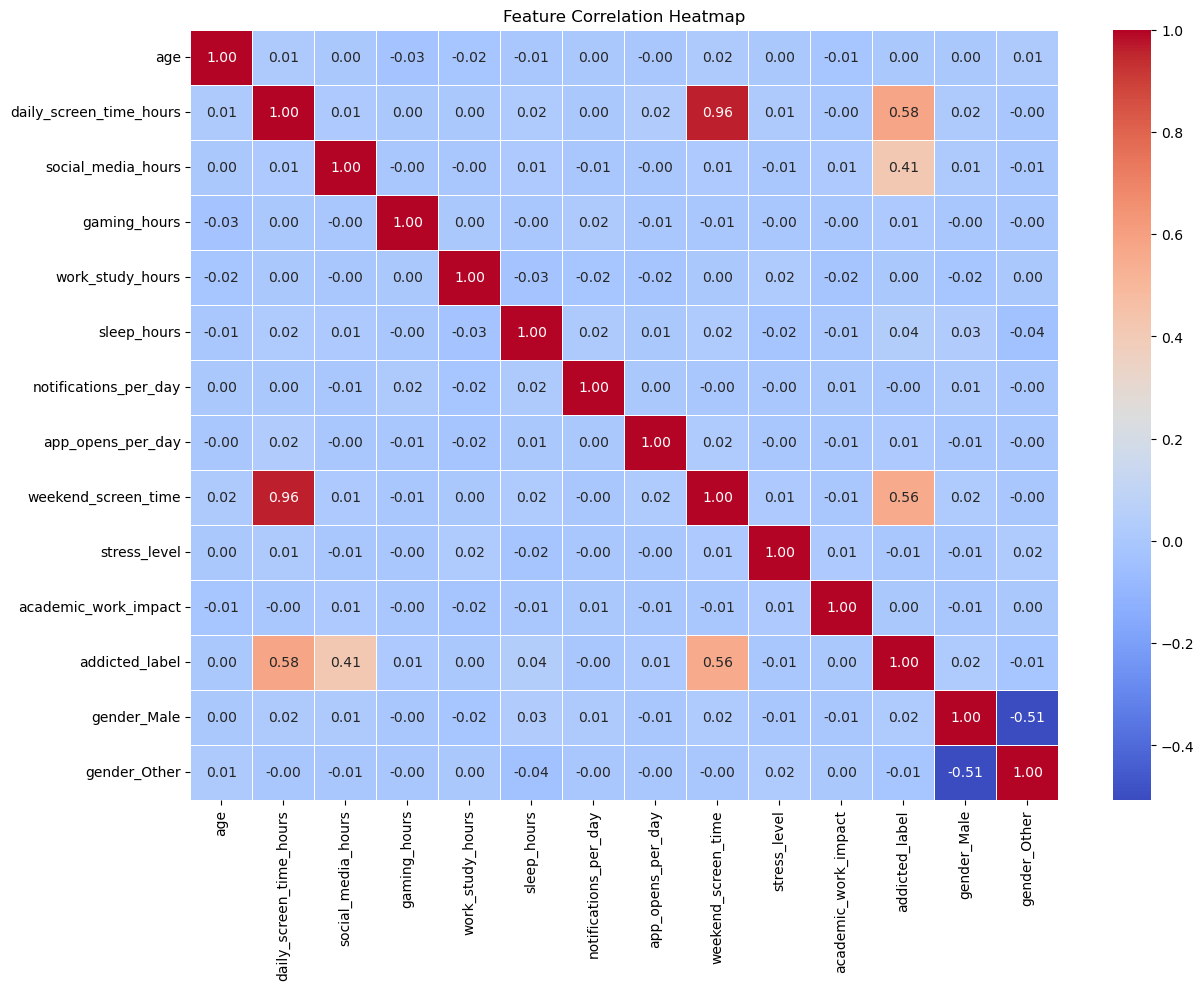

In [16]:
# Calculate Correlation Matrix
corr_matrix = df_cleaned.corr()
# Visualize Correlation Matrix using a Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [17]:
# Extracting the features most correlated with the target variable
print("\nFeatures most correlated with 'addicted_label':")
print(corr_matrix['addicted_label'].sort_values(ascending=False))


Features most correlated with 'addicted_label':
addicted_label             1.000000
daily_screen_time_hours    0.577112
weekend_screen_time        0.555426
social_media_hours         0.414244
sleep_hours                0.035496
gender_Male                0.022989
app_opens_per_day          0.011041
gaming_hours               0.008485
age                        0.004220
work_study_hours           0.001103
academic_work_impact       0.000072
notifications_per_day     -0.000660
stress_level              -0.007615
gender_Other              -0.014589
Name: addicted_label, dtype: float64


## 5. Machine Learning (Logistic Regression)
 *We use Logistic Regression as it is the standard regression technique for predicting binary outcomes (0 or 1).*

In [18]:
# Split data into Features (X) and Target (y)
X = df_cleaned.drop('addicted_label', axis=1)
y = df_cleaned['addicted_label']

In [19]:
# Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [20]:
# Feature Scaling (Standardization is important for linear/logistic regression models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
# Initialize and Train the Logistic Regression Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [22]:
# Make Predictions
y_pred = log_reg.predict(X_test_scaled)

 ## 6. Model Evaluation

In [23]:
# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")


Model Accuracy: 88.93%



In [24]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       438
           1       0.91      0.94      0.92      1062

    accuracy                           0.89      1500
   macro avg       0.87      0.86      0.86      1500
weighted avg       0.89      0.89      0.89      1500



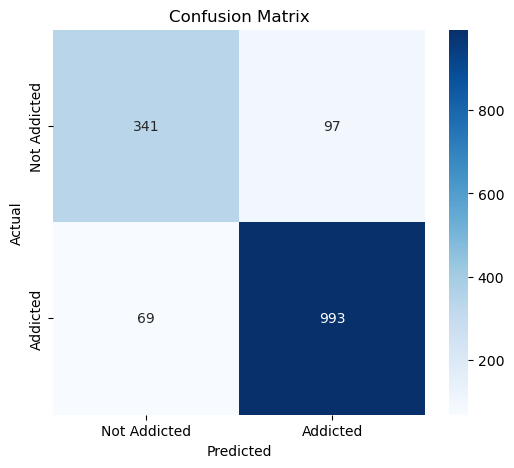

In [25]:
# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Addicted', 'Addicted'], yticklabels=['Not Addicted', 'Addicted'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

C:\Users\waelw\AppData\Local\Temp\ipykernel_2352\860448469.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='mako')


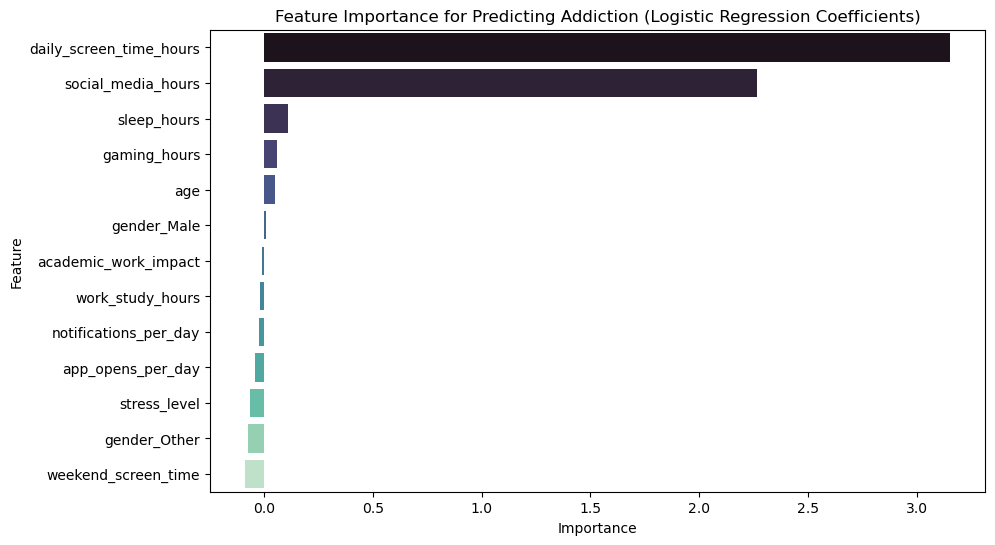

In [26]:
# Visualizing Feature Importance (Coefficients of the Logistic Regression)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': log_reg.coef_[0]})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='mako')
plt.title('Feature Importance for Predicting Addiction (Logistic Regression Coefficients)')
plt.show()

In [27]:
pip install streamlit joblib

  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1
Note: you may need to restart the kernel to use updated packages.


In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

# 2. Clean and drop leakage columns
df_cleaned = df.drop(['transaction_id', 'user_id', 'addiction_level'], axis=1)

# 3. Map categorical variables to numbers
df_cleaned['stress_level'] = df_cleaned['stress_level'].map({'Low': 0, 'Medium': 1, 'High': 2})
df_cleaned['academic_work_impact'] = df_cleaned['academic_work_impact'].map({'No': 0, 'Yes': 1})
df_cleaned['gender'] = df_cleaned['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})

# 4. Split into Features (X) and Target (y)
X = df_cleaned.drop('addicted_label', axis=1)
y = df_cleaned['addicted_label']

# 5. Train-Test Split (80% Train, 20% Test) using stratify to keep classes balanced
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Train the Random Forest Model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# 7. Save the trained model to a file
joblib.dump(rf_model, 'rf_model.pkl')
print("Model trained and saved successfully as 'rf_model.pkl'")

Model trained and saved successfully as 'rf_model.pkl'


Random Forest Model Accuracy: 93.07%

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.90      0.88       438
           1       0.96      0.94      0.95      1062

    accuracy                           0.93      1500
   macro avg       0.91      0.92      0.92      1500
weighted avg       0.93      0.93      0.93      1500



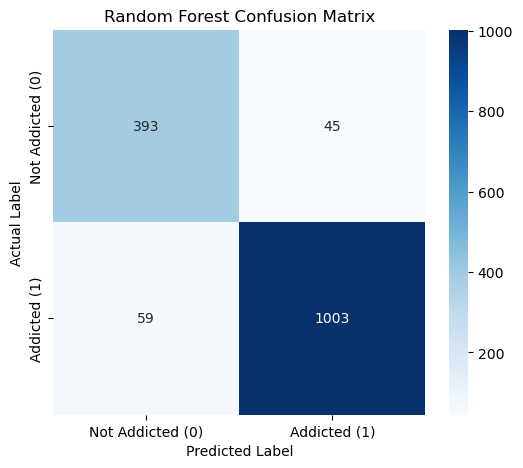

C:\Users\waelw\AppData\Local\Temp\ipykernel_2352\3857437224.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


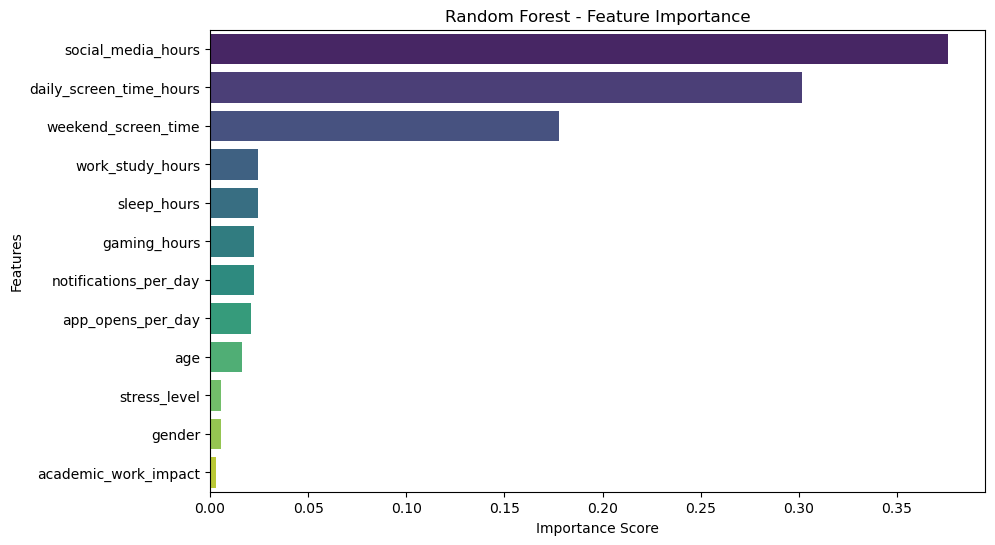

In [31]:
# --- Model Evaluation for Random Forest ---
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions on the testing data
y_pred = rf_model.predict(X_test)

# 2. Calculate and Print Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Model Accuracy: {accuracy * 100:.2f}%\n")

# 3. Print the Classification Report (Precision, Recall, F1-Score)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Addicted (0)', 'Addicted (1)'], 
            yticklabels=['Not Addicted (0)', 'Addicted (1)'])
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Random Forest Confusion Matrix')
plt.show()

# 5. Plot Feature Importance (What features does the Random Forest care about most?)
feature_importance = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()